In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'


✅ Libraries imported successfully.


In [ ]:
# ── Update this path to wherever your CSV file is located ──
FILE_PATH = 'cleaned_gas_monitoring.csv'

df = pd.read_csv(FILE_PATH)

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 6,410 rows × 14 columns


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,very_bright,Low Activity
2,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,1.0,7241,eco_mode,very_bright,High Activity
3,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity
4,night,20.04,48.42,118.293529,582.624643,474.777417,736.890795,694.939447,628.884980,1.0,6431,heating_active,bright,Low Activity


In [ ]:
info_df = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().mean() * 100).round(2).values,
    'Unique Values': df.nunique().values
})
info_df

,Column,Dtype,Non-Null Count,Null Count,Null %,Unique Values
0,Time of Day,object,6410,0,0.0,4
1,Temperature,float64,6410,0,0.0,946
2,Humidity,float64,6410,0,0.0,1442
3,CO2_InfraredSensor,float64,6410,0,0.0,5934
4,CO2_ElectroChemicalSensor,float64,6410,0,0.0,5934
5,MetalOxideSensor_Unit1,float64,6410,0,0.0,5934
6,MetalOxideSensor_Unit2,float64,6410,0,0.0,5145
7,MetalOxideSensor_Unit3,float64,6410,0,0.0,5934
8,MetalOxideSensor_Unit4,float64,6410,0,0.0,5934
9,CO_GasSensor,float64,6410,0,0.0,4


In [ ]:
df['HVAC_clean'] = df['HVAC Operation Mode'].str.strip().str.lower()
df['Activity_clean'] = (df['Activity Level']
                        .str.strip()
                        .str.lower()
                        .str.replace('_', ' ', regex=False))

print("HVAC after cleaning:", sorted(df['HVAC_clean'].unique()))
print("\nActivity after cleaning:", sorted(df['Activity_clean'].unique()))

HVAC after cleaning: ['cooling_active', 'eco_mode', 'heating_active', 'maintenance_mode', 'off', 'ventilation_only']

Activity after cleaning: ['high activity', 'low activity', 'lowactivity', 'moderate activity', 'moderateactivity']


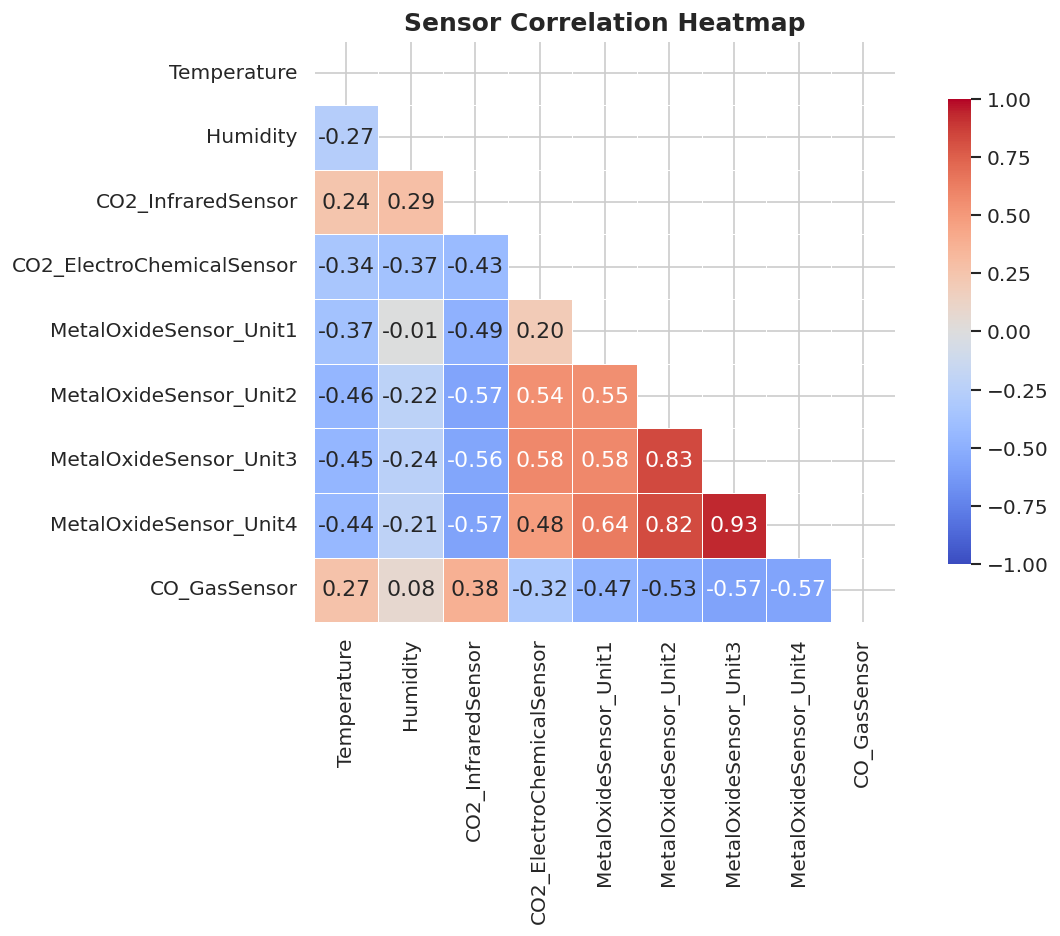


📌 Observation: The four Metal Oxide Sensors are highly correlated with each other.
   The two CO2 sensors show weak correlation — they may measure different gas components.


In [ ]:
corr = df[sensor_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Sensor Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

This shows that the four metal oxide sensors are highly correlated with each other. The two CO2 sensors show weak correlation, meaning they might measure different compoenents or areas.

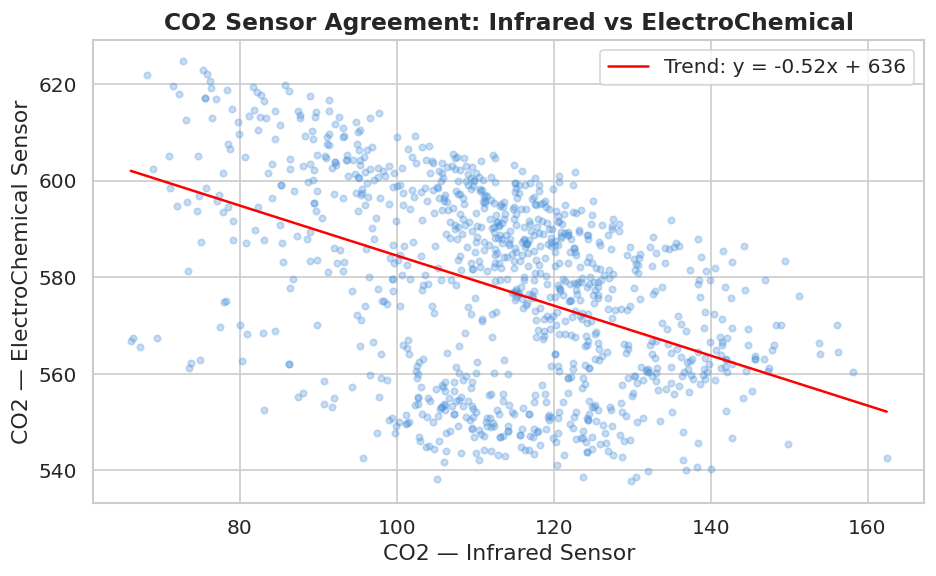


📌 Observation: The two CO2 sensors show limited agreement, suggesting they capture different ranges or measurement principles.


In [ ]:
sample = df.sample(min(1000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample['CO2_InfraredSensor'], sample['CO2_ElectroChemicalSensor'],
           alpha=0.3, s=15, color='#4a90d9')

# Trend line
m, b = np.polyfit(sample['CO2_InfraredSensor'], sample['CO2_ElectroChemicalSensor'], 1)
x_line = np.linspace(sample['CO2_InfraredSensor'].min(), sample['CO2_InfraredSensor'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5, label=f'Trend: y = {m:.2f}x + {b:.0f}')

ax.set_xlabel('CO2 — Infrared Sensor')
ax.set_ylabel('CO2 — ElectroChemical Sensor')
ax.set_title('CO2 Sensor Agreement: Infrared vs ElectroChemical')
ax.legend()
plt.tight_layout()
plt.show()

With further observation, the two CO2 sensors do seem to be a little bit related with the general data being when the infrared sensor decreases, the electrochemical sensor increases. However, there are many outliers so their relationship is very weak or does not exist.

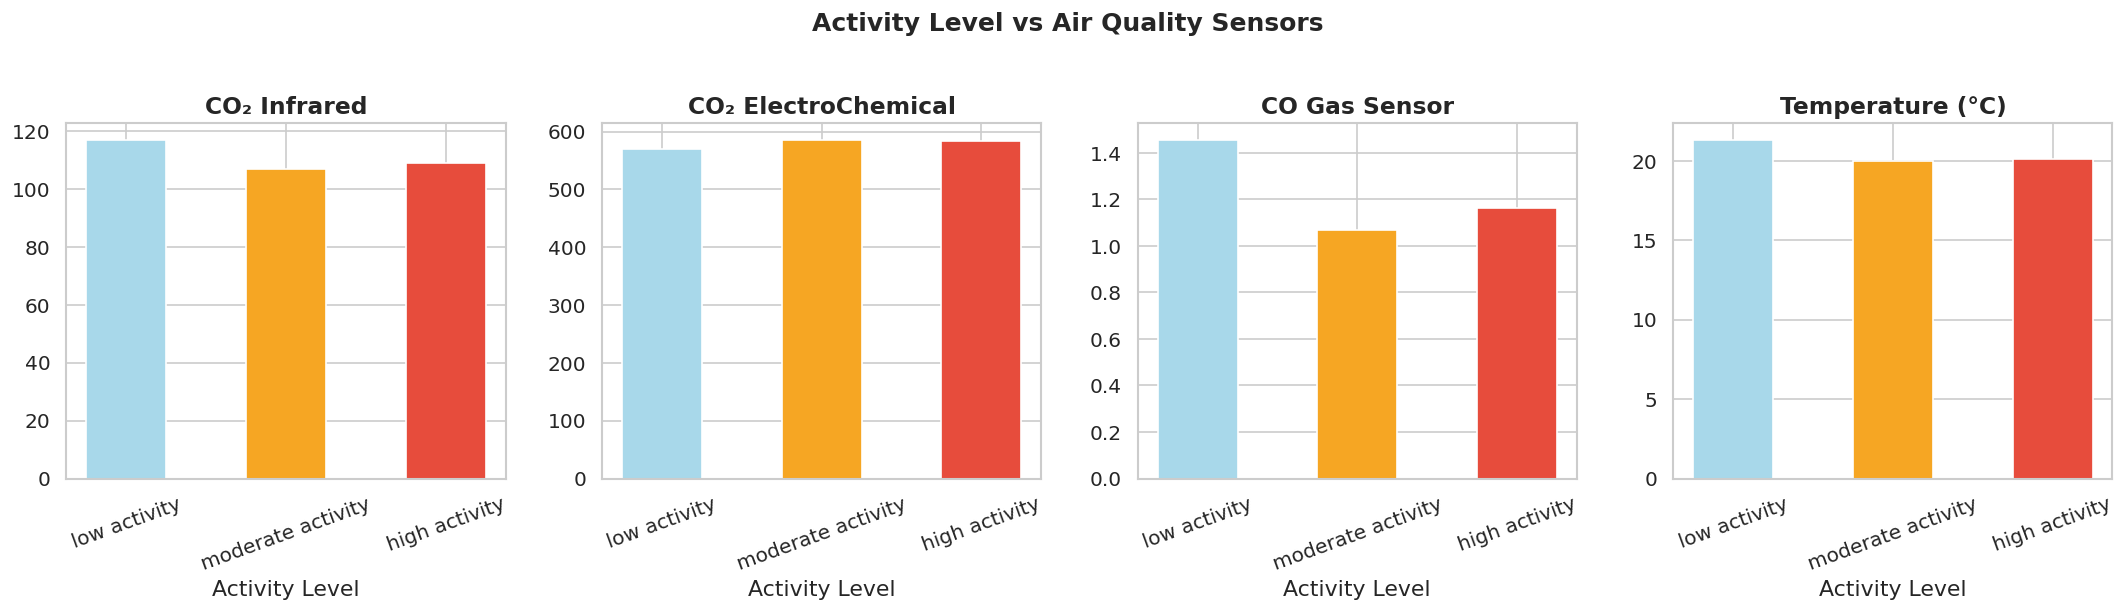


📌 Observation: Higher activity levels correlate with elevated CO2 readings — consistent with increased occupancy and respiration.


In [ ]:
act_order = ['low activity', 'moderate activity', 'high activity']
df_act = df[df['Activity_clean'].isin(act_order)].copy()

metrics_act = ['CO2_InfraredSensor', 'CO2_ElectroChemicalSensor', 'CO_GasSensor', 'Temperature']
titles_act = ['CO₂ Infrared', 'CO₂ ElectroChemical', 'CO Gas Sensor', 'Temperature (°C)']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
palette3 = ['#a8d8ea', '#f6a623', '#e74c3c']

for i, (col, title) in enumerate(zip(metrics_act, titles_act)):
    means = df_act.groupby('Activity_clean')[col].mean().reindex(act_order)
    axes[i].bar(means.index, means.values, color=palette3, edgecolor='white', width=0.5)
    axes[i].set_title(title)
    axes[i].set_xlabel('Activity Level')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Activity Level vs Air Quality Sensors', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Lower activity levels generally correlate to higher CO2 readings, suggesting that maybe ventilation is better when there is more activity or the sensors are isolated away from human activity

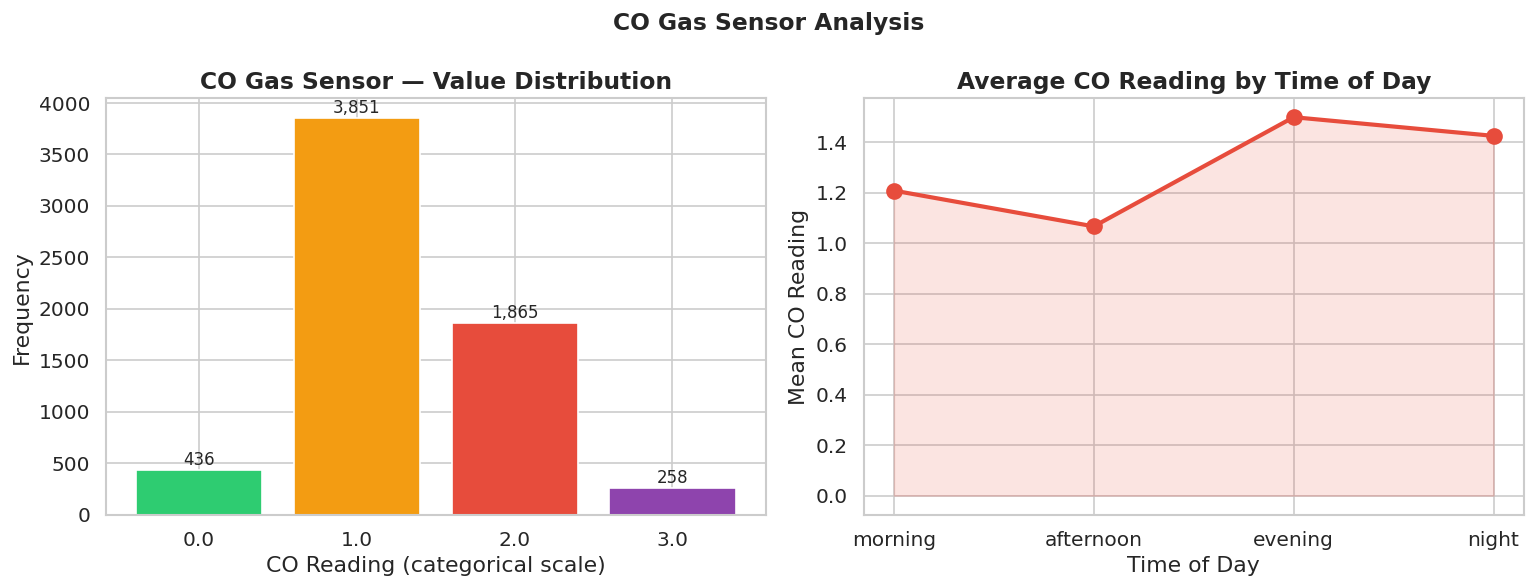


📌 Observation: Most CO readings are at level 1 (safe). Elevated readings (2–3) are less frequent and may warrant investigation.


In [ ]:
co_counts = df['CO_GasSensor'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart of CO levels
bars = axes[0].bar(co_counts.index.astype(str), co_counts.values,
                   color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'], edgecolor='white')
axes[0].set_title('CO Gas Sensor — Value Distribution')
axes[0].set_xlabel('CO Reading (categorical scale)')
axes[0].set_ylabel('Frequency')
for bar, val in zip(bars, co_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# CO by Time of Day
co_by_time = df.groupby('Time of Day')['CO_GasSensor'].mean().reindex(time_order)
axes[1].plot(time_order, co_by_time.values, marker='o', linewidth=2.5,
             color='#e74c3c', markersize=9)
axes[1].fill_between(time_order, co_by_time.values, alpha=0.15, color='#e74c3c')
axes[1].set_title('Average CO Reading by Time of Day')
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Mean CO Reading')

plt.suptitle('CO Gas Sensor Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Most CO readings are at level 1 which is safe, however there are less frequent 2-3 readings which may require extra attention

## 11. Metal Oxide Sensors — Unit Comparison

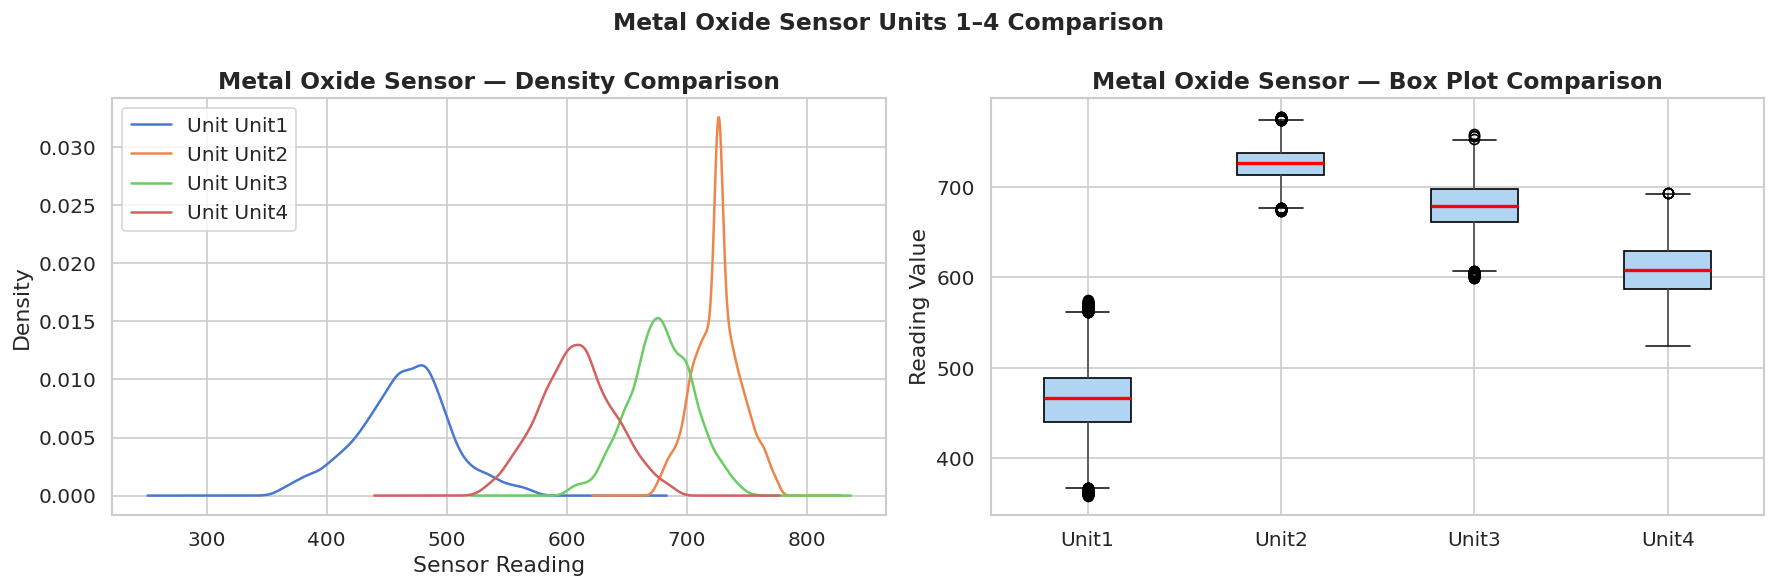


📌 Observation: Units 2 and 3 show higher median readings and greater spread than Units 1 and 4.


In [ ]:
mox_cols = ['MetalOxideSensor_Unit1', 'MetalOxideSensor_Unit2',
            'MetalOxideSensor_Unit3', 'MetalOxideSensor_Unit4']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# KDE overlay
for col in mox_cols:
    df[col].plot.kde(ax=axes[0], label=col.replace('MetalOxideSensor_', 'Unit '))
axes[0].set_title('Metal Oxide Sensor — Density Comparison')
axes[0].set_xlabel('Sensor Reading')
axes[0].legend()

# Box plots side by side
df[mox_cols].rename(columns=lambda x: x.replace('MetalOxideSensor_', '')).boxplot(
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='#b0d4f1'),
    medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Metal Oxide Sensor — Box Plot Comparison')
axes[1].set_ylabel('Reading Value')

plt.suptitle('Metal Oxide Sensor Units 1–4 Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Unit 2 shows the highest median reafing whilst Unit 1 shows the lowers, suggesting that unit 2 is placed closer to high metal oxide areas while unit 1 is placed further away.